# ICU Data Understanding — Versi 2 (Rapi)

Notebook ini adalah versi kedua yang disusun ulang dari dasar sesuai alur **Data Understanding (D1–D8)**.
Seluruh gambar di-generate murni dari kode dan menggunakan suffix ****.

## Langkah 0 — Setup, Load Data, dan Konfigurasi Folder

In [1]:
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = 'dataset/ICU_Patient_Monitoring_Mortality_Prediction_15000.csv'
FIG_DIR = Path('figures')
OUT_DIR = Path('outputs')
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
with open(DATA_PATH, 'rb') as f:
    file_sha256 = hashlib.sha256(f.read()).hexdigest()

print('Shape:', df.shape)
print('Columns:', len(df.columns))
print('SHA256:', file_sha256)
display(df.head(3))

Shape: (15000, 24)
Columns: 24
SHA256: c3a11947ebf061a2462c23f80152d4ed7e3d787b0537c6dedc34bcf7b7c0db69


,patient_id,age,gender,admission_type,comorbidity_score,heart_rate_mean,heart_rate_std,heart_rate_max,heart_rate_min,systolic_bp_mean,...,glucose_mean,lactate_mean,urine_output_total,ventilation_required,vasopressor_used,length_of_stay_days,apache_score,sofa_score,sepsis_flag,mortality_label
0,PAT000001,32,Male,Urgent,3.75,136.06,19.64,162.01,127.16,104.04,...,73.71,7.77,4245.99,0,0,6.32,15.65,10.50,0,0
1,PAT000002,46,Male,Urgent,2.91,108.95,7.79,124.18,94.79,131.05,...,78.36,5.06,1267.36,0,1,29.00,33.29,6.09,0,1
2,PAT000003,87,Male,Urgent,6.84,95.21,7.44,117.54,89.35,171.84,...,168.41,1.89,4863.13,1,1,26.95,25.93,18.44,0,1


**Interpretasi:** dataset berhasil dimuat sebagai basis seluruh analisis D1–D8.

## D1 — Data Card (Provenance, Schema, Limitations)

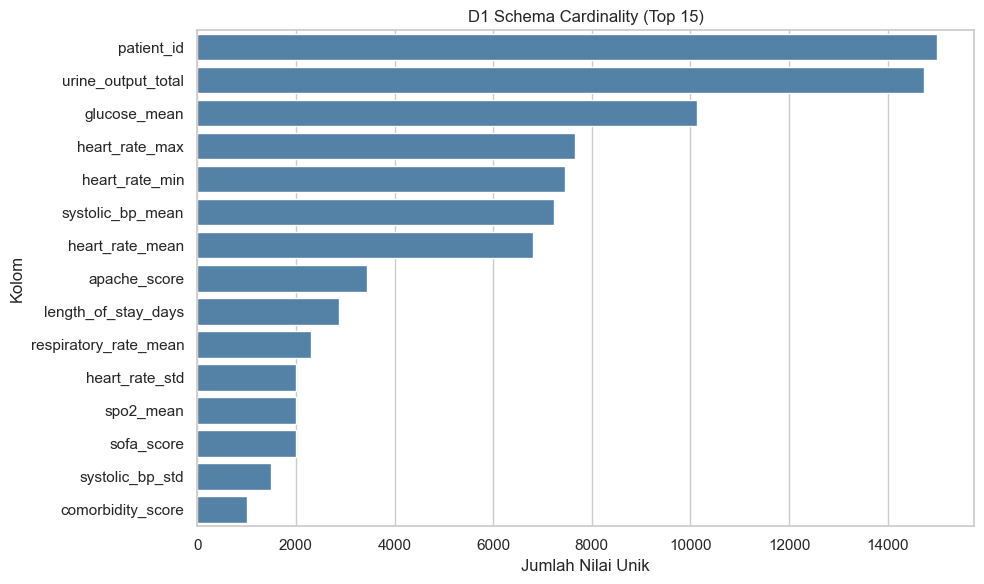

,column_name,dtype,n_unique,missing_%
0,patient_id,str,15000,0.0
1,age,int64,73,0.0
2,gender,str,2,0.0
3,admission_type,str,3,0.0
4,comorbidity_score,float64,1001,0.0
5,heart_rate_mean,float64,6806,0.0
6,heart_rate_std,float64,2001,0.0
7,heart_rate_max,float64,7651,0.0
8,heart_rate_min,float64,7447,0.0
9,systolic_bp_mean,float64,7226,0.0


In [ ]:
schema_df = pd.DataFrame({
    'column_name': df.columns,
    'dtype': [str(df[c].dtype) for c in df.columns],
    'n_unique': [df[c].nunique() for c in df.columns],
    'missing_%': [df[c].isna().mean() * 100 for c in df.columns]
})

data_card_text = f'''# Data Card ICU

## Provenance
- Sumber: Kaggle (jayjoshi37)
- File: {DATA_PATH}
- Ukuran: {df.shape[0]} baris x {df.shape[1]} kolom
- SHA256: {file_sha256}

## Ringkasan Struktur
- Missing total: {int(df.isna().sum().sum())}
- Duplicate rows: {int(df.duplicated().sum())}
- Target: mortality_label

## Limitations
- Data cross-sectional (bukan time-series event-level).
- Detail provenance institusi tidak tersedia publik.
- Fairness prediktif perlu model baseline.
'''
(OUT_DIR / 'Data_Card_ICU.md').write_text(data_card_text, encoding='utf-8')

plt.figure(figsize=(10, 6))
schema_top = schema_df.sort_values('n_unique', ascending=False).head(15)
sns.barplot(data=schema_top, x='n_unique', y='column_name', color='steelblue')
plt.title('D1 Schema Cardinality (Top 15)')
plt.xlabel('Jumlah Nilai Unik')
plt.ylabel('Kolom')
plt.tight_layout()
plt.savefig(FIG_DIR / 'du_step01_d1_schema_cardinality.png', dpi=150, bbox_inches='tight')
plt.show()

display(schema_df.head(10))

**Interpretasi:** Data Card dan skema sudah dibentuk di awal alur (benar secara metodologis), serta diekspor ke file terpisah.

## D2 — Representativeness & Bias Audit

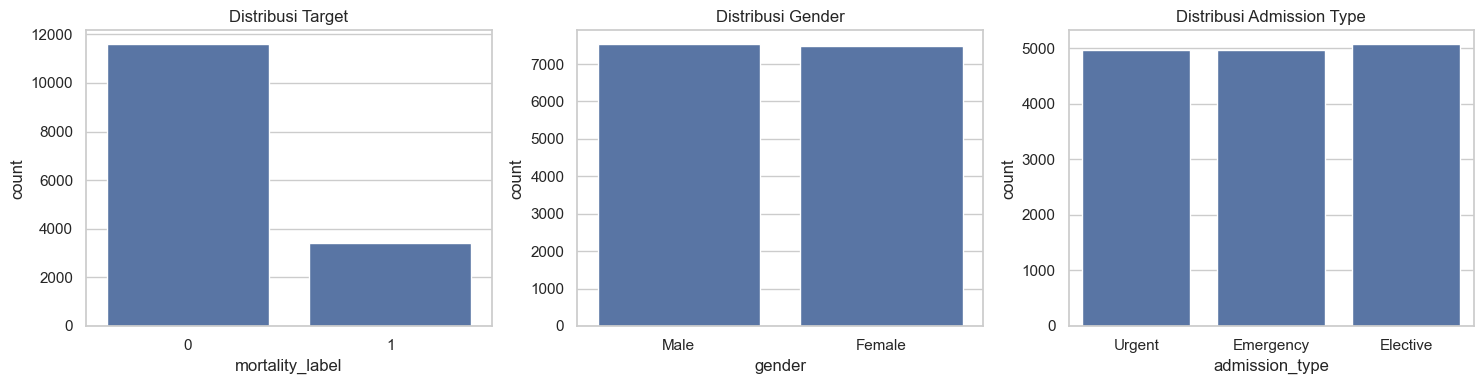

In [3]:
target_counts = df['mortality_label'].value_counts().sort_index()
prevalence = df['mortality_label'].mean()
baseline_majority = max(prevalence, 1-prevalence)
imbalance_ratio = target_counts.max() / target_counts.min()

df_bias = df.copy()
df_bias['age_group'] = pd.cut(df_bias['age'], bins=[17,39,59,90], labels=['18-39','40-59','60-90'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x='mortality_label', ax=axes[0])
axes[0].set_title('Distribusi Target')
sns.countplot(data=df, x='gender', ax=axes[1])
axes[1].set_title('Distribusi Gender')
sns.countplot(data=df, x='admission_type', ax=axes[2])
axes[2].set_title('Distribusi Admission Type')
plt.tight_layout()
plt.savefig(FIG_DIR / 'du_step02_d2_representativeness_counts.png', dpi=150, bbox_inches='tight')
plt.show()



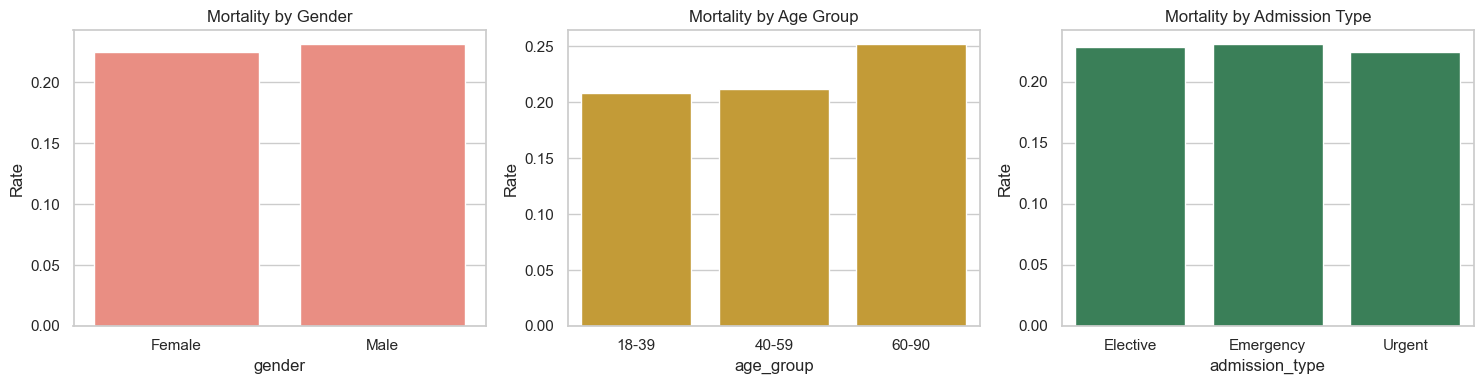

Prevalence: 0.2279
Baseline majority accuracy: 0.7721
Imbalance ratio: 3.389


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(x=df_bias.groupby('gender')['mortality_label'].mean().index,
            y=df_bias.groupby('gender')['mortality_label'].mean().values, ax=axes[0], color='salmon')
axes[0].set_title('Mortality by Gender')
sns.barplot(x=df_bias.groupby('age_group', observed=False)['mortality_label'].mean().index.astype(str),
            y=df_bias.groupby('age_group', observed=False)['mortality_label'].mean().values, ax=axes[1], color='goldenrod')
axes[1].set_title('Mortality by Age Group')
sns.barplot(x=df_bias.groupby('admission_type')['mortality_label'].mean().index,
            y=df_bias.groupby('admission_type')['mortality_label'].mean().values, ax=axes[2], color='seagreen')
axes[2].set_title('Mortality by Admission Type')
for ax in axes:
    ax.set_ylabel('Rate')
plt.tight_layout()
plt.savefig(FIG_DIR / 'du_step03_d2_bias_audit.png', dpi=150, bbox_inches='tight')
plt.show()

print('Prevalence:', round(prevalence, 4))
print('Baseline majority accuracy:', round(baseline_majority, 4))
print('Imbalance ratio:', round(imbalance_ratio, 3))

**Interpretasi:** representativeness dan audit bias dasar ditampilkan lengkap dengan visual distribusi dan subgroup mortality.

## D3 — Advanced EDA (Distribusi, Missing, Outlier, Korelasi)

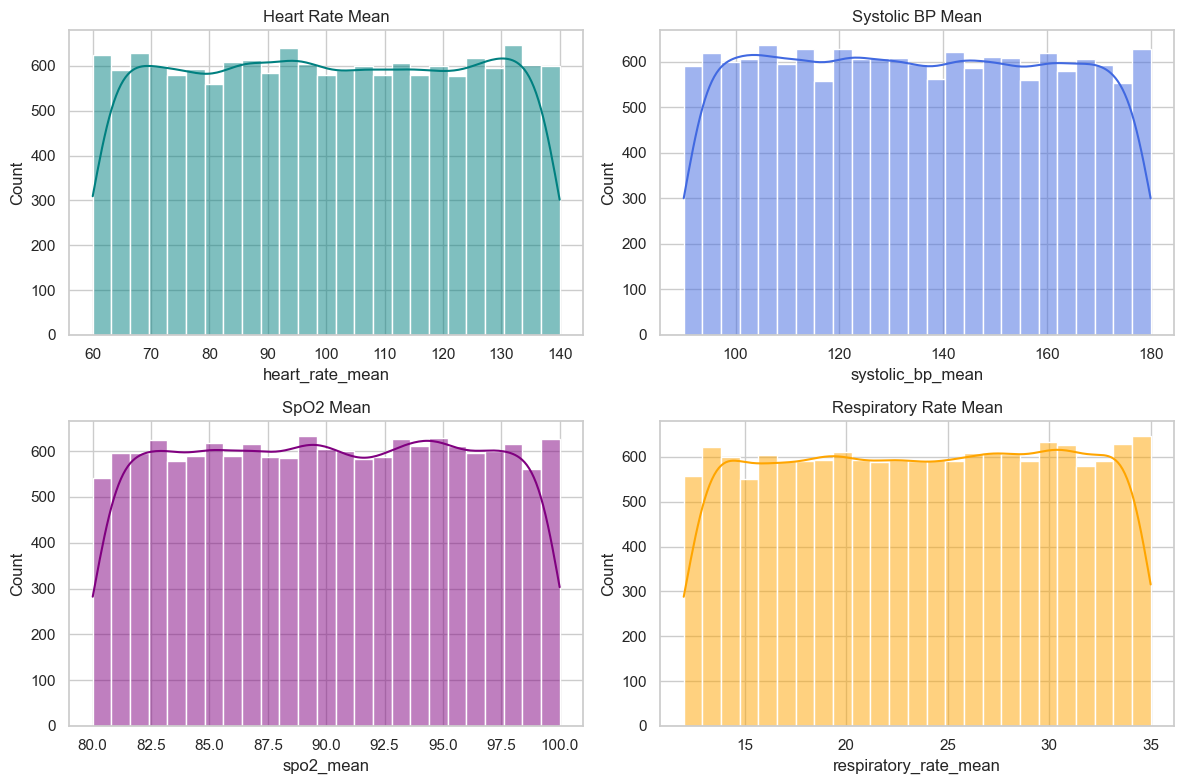

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['heart_rate_mean'], kde=True, ax=axes[0,0], color='teal')
axes[0,0].set_title('Heart Rate Mean')
sns.histplot(df['systolic_bp_mean'], kde=True, ax=axes[0,1], color='royalblue')
axes[0,1].set_title('Systolic BP Mean')
sns.histplot(df['spo2_mean'], kde=True, ax=axes[1,0], color='purple')
axes[1,0].set_title('SpO2 Mean')
sns.histplot(df['respiratory_rate_mean'], kde=True, ax=axes[1,1], color='orange')
axes[1,1].set_title('Respiratory Rate Mean')
plt.tight_layout()
plt.savefig(FIG_DIR / 'du_step04_d3_vital_distributions.png', dpi=150, bbox_inches='tight')
plt.show()



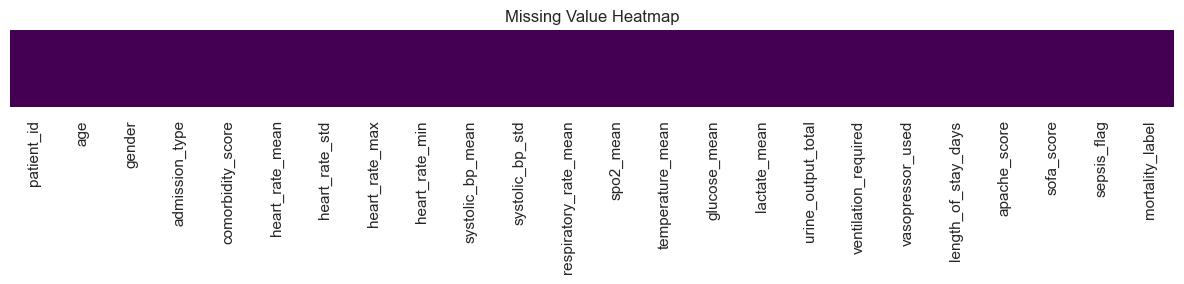

In [ ]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 3))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.savefig(FIG_DIR / 'du_step05_d3_missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

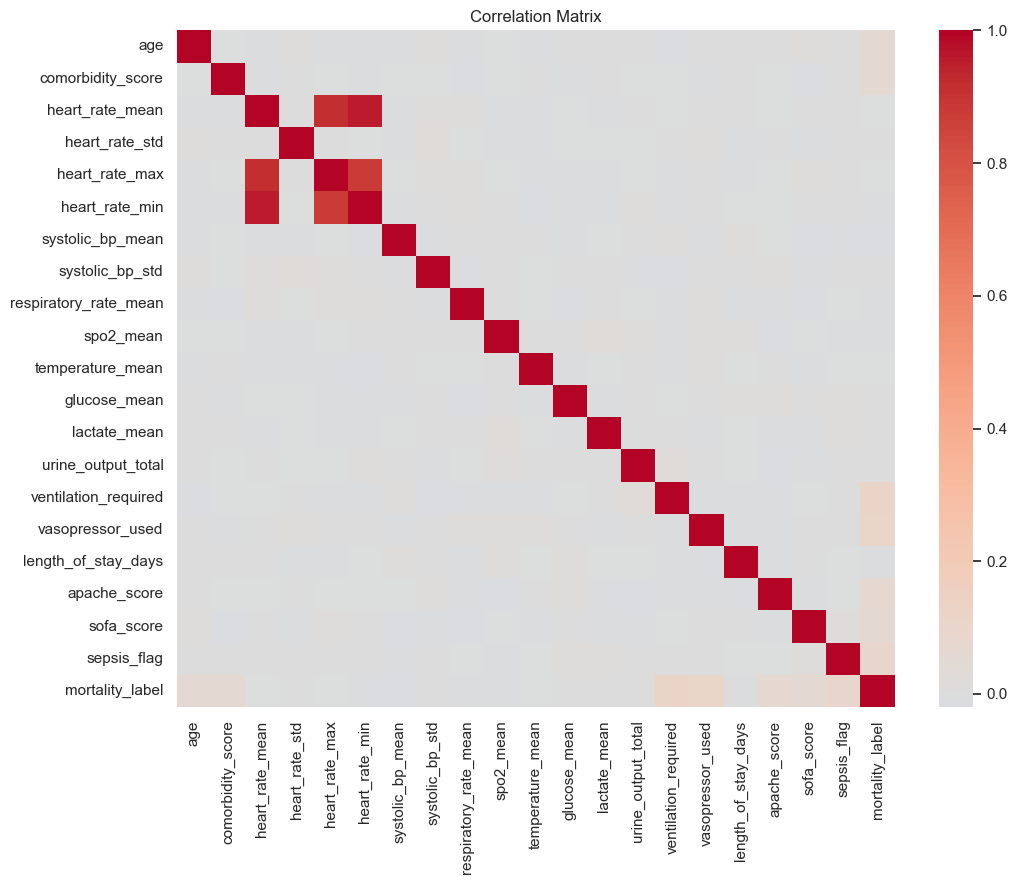

In [7]:
corr = df[num_cols].corr(numeric_only=True)
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / 'du_step06_d3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
num_cols_wo_target = [c for c in num_cols if c != 'mortality_label']
q1 = df[num_cols_wo_target].quantile(0.25)
q3 = df[num_cols_wo_target].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_count = ((df[num_cols_wo_target] < lower) | (df[num_cols_wo_target] > upper)).sum().sort_values(ascending=False)
display(pd.DataFrame({'outlier_count': outlier_count, 'outlier_pct': (outlier_count/len(df)*100).round(3)}).head(10))

,outlier_count,outlier_pct
vasopressor_used,3677,24.513
sepsis_flag,3029,20.193
age,0,0.000
comorbidity_score,0,0.000
heart_rate_std,0,0.000
heart_rate_mean,0,0.000
heart_rate_max,0,0.000
heart_rate_min,0,0.000
respiratory_rate_mean,0,0.000
spo2_mean,0,0.000


**Interpretasi:** EDA lanjutan sudah mencakup distribusi, missing, outlier, dan dependency structure.

## D4 — Semantic Validation & Leakage Checklist

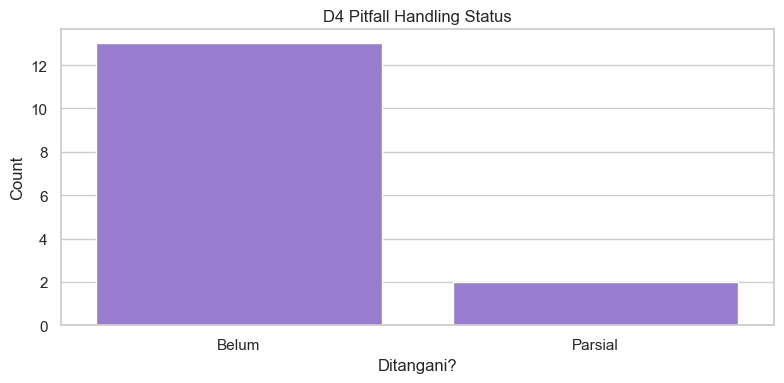

In [9]:
potential_identifier = [c for c in df.columns if c.lower().endswith('_id') or 'patient' in c.lower()]
potential_leakage = [c for c in df.columns if 'mortality' in c.lower() and c != 'mortality_label']
hr_order_ok = ((df['heart_rate_min'] <= df['heart_rate_mean']) & (df['heart_rate_mean'] <= df['heart_rate_max'])).mean() * 100

pitfall_items = [
    'Target Leakage','Temporal Leakage','Pipeline Leakage','Feature Selection Leakage','Augmentation Leakage',
    'Duplicate Data','Class Imbalance -> Accuracy Illusion','High Dimensionality (p >> n)','Wrong Split Strategy',
    'Sequential Overfitting','Wrong Metric Selection','Proxy Bias','Multiple Comparison Risk',
    'MNAR tanpa model eksplisit','Missing Provenance'
]

pitfall_checklist = pd.DataFrame({
    'No': range(1,16),
    'Pitfall': pitfall_items,
    'Terdeteksi?': ['Ya' if p in ['Class Imbalance -> Accuracy Illusion','Wrong Metric Selection','Proxy Bias'] else 'Perlu verifikasi lanjutan' for p in pitfall_items],
    'Ditangani?': ['Parsial' if p in ['Class Imbalance -> Accuracy Illusion','Wrong Metric Selection'] else 'Belum' for p in pitfall_items]
})
pitfall_checklist.to_csv(OUT_DIR / 'pitfall_checklist.csv', index=False, encoding='utf-8-sig')

plt.figure(figsize=(8,4))
status_counts = pitfall_checklist['Ditangani?'].value_counts()
sns.barplot(x=status_counts.index, y=status_counts.values, color='mediumpurple')
plt.title('D4 Pitfall Handling Status')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(FIG_DIR / 'du_step07_d4_pitfall_status.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print('Identifier:', potential_identifier)
print('Potential leakage columns:', potential_leakage)
print('HR logical consistency (%):', round(hr_order_ok, 2))
display(pitfall_checklist.head())

Identifier: ['patient_id']
Potential leakage columns: []
HR logical consistency (%): 100.0


,No,Pitfall,Terdeteksi?,Ditangani?
0,1,Target Leakage,Perlu verifikasi lanjutan,Belum
1,2,Temporal Leakage,Perlu verifikasi lanjutan,Belum
2,3,Pipeline Leakage,Perlu verifikasi lanjutan,Belum
3,4,Feature Selection Leakage,Perlu verifikasi lanjutan,Belum
4,5,Augmentation Leakage,Perlu verifikasi lanjutan,Belum


**Interpretasi:** validasi semantik dan checklist leakage sudah terdokumentasi serta diekspor.

## D5 — Data Quality Report (ISO/IEC 25012)

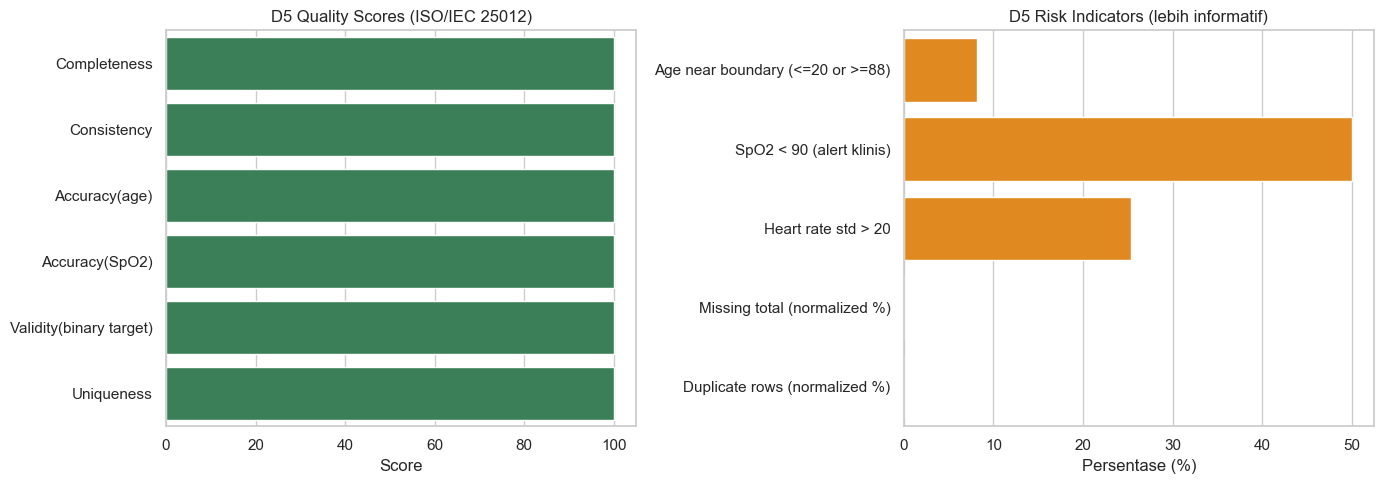

,dimension,score_or_note
0,Completeness,100.0
1,Consistency,100.0
2,Accuracy(age),100.0
3,Accuracy(SpO2),100.0
4,Validity(binary target),100.0
5,Uniqueness,100.0
6,Timeliness,Cross-sectional tanpa timestamp event-level


,indikator,nilai_persen
0,Age near boundary (<=20 or >=88),8.19
1,SpO2 < 90 (alert klinis),49.95
2,Heart rate std > 20,25.36
3,Missing total (normalized %),0.00
4,Duplicate rows (normalized %),0.00


In [17]:
quality_df = pd.DataFrame({
    'dimension': ['Completeness','Consistency','Accuracy(age)','Accuracy(SpO2)','Validity(binary target)','Uniqueness','Timeliness'],
    'score_or_note': [
        round(100 - (df.isna().mean().max() * 100), 2),
        round(((df['heart_rate_min'] <= df['heart_rate_mean']) & (df['heart_rate_mean'] <= df['heart_rate_max'])).mean() * 100, 2),
        round(df['age'].between(18, 90).mean() * 100, 2),
        round(df['spo2_mean'].between(70, 100).mean() * 100, 2),
        round(df['mortality_label'].isin([0,1]).mean() * 100, 2),
        round((1 - df.duplicated().mean()) * 100, 2),
        'Cross-sectional tanpa timestamp event-level'
    ]
})
quality_df.to_csv(OUT_DIR / 'data_quality_report.csv', index=False, encoding='utf-8-sig')

qplot = quality_df[quality_df['dimension'] != 'Timeliness'].copy()
qplot['score_or_note'] = qplot['score_or_note'].astype(float)

risk_df = pd.DataFrame({
    'indikator': [
        'Age near boundary (<=20 or >=88)',
        'SpO2 < 90 (alert klinis)',
        'Heart rate std > 20',
        'Missing total (normalized %)',
        'Duplicate rows (normalized %)'
    ],
    'nilai_persen': [
        round(((df['age'] <= 20) | (df['age'] >= 88)).mean() * 100, 2),
        round((df['spo2_mean'] < 90).mean() * 100, 2),
        round((df['heart_rate_std'] > 20).mean() * 100, 2),
        round((df.isna().sum().sum() / (df.shape[0] * df.shape[1])) * 100, 4),
        round((df.duplicated().sum() / len(df)) * 100, 4)
    ]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=qplot, x='score_or_note', y='dimension', color='seagreen', ax=axes[0])
axes[0].set_title('D5 Quality Scores (ISO/IEC 25012)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('')

sns.barplot(data=risk_df, x='nilai_persen', y='indikator', color='darkorange', ax=axes[1])
axes[1].set_title('D5 Risk Indicators (lebih informatif)')
axes[1].set_xlabel('Persentase (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(FIG_DIR / 'du_step08_d5_quality_scores.png', dpi=150, bbox_inches='tight')
plt.show()

display(quality_df)
display(risk_df)

**Interpretasi:** enam dimensi kualitas utama tetap tinggi, namun kini visual D5 juga menyertakan indikator risiko operasional (mis. proporsi SpO2 < 90, usia dekat batas, dan variabilitas HR tinggi) agar analisis tidak terlihat “flat” meskipun skor kualitas inti bernilai 100.

## D6 — Evaluation Design Plan

In [20]:
evaluation_plan = pd.DataFrame({
    'komponen': ['Split strategy','Stratifikasi','Baseline','Metrik utama','Catatan leakage'],
    'rencana': [
        'Train/Valid/Test = 70/15/15',
        'Ya, stratify = mortality_label',
        f'Majority accuracy = {round(max(df["mortality_label"].mean(), 1-df["mortality_label"].mean()), 4)}',
        'PR-AUC, Recall, F1, MCC (+ ROC-AUC)',
        'Drop patient_id; fit preprocessing hanya pada train set'
    ]
})
evaluation_plan.to_csv(OUT_DIR / 'evaluation_plan.csv', index=False, encoding='utf-8-sig')

md_lines = ["| komponen | rencana |", "|---|---|"]
for _, row in evaluation_plan.iterrows():
    komp = str(row['komponen']).replace('|', '\\|')
    rencana = str(row['rencana']).replace('|', '\\|')
    md_lines.append(f"| {komp} | {rencana} |")
(OUT_DIR / 'evaluation_plan.md').write_text("\n".join(md_lines), encoding='utf-8')

display(evaluation_plan)

,komponen,rencana
0,Split strategy,Train/Valid/Test = 70/15/15
1,Stratifikasi,"Ya, stratify = mortality_label"
2,Baseline,Majority accuracy = 0.7721
3,Metrik utama,"PR-AUC, Recall, F1, MCC (+ ROC-AUC)"
4,Catatan leakage,Drop patient_id; fit preprocessing hanya pada ...


**Interpretasi:** D6 difokuskan sebagai artefak tabel rencana evaluasi (CSV/Markdown). Visual bar `Included=1` dihapus karena tidak menambah informasi analitis.

## D7 — Fairness & Ethical Audit (Deskriptif)

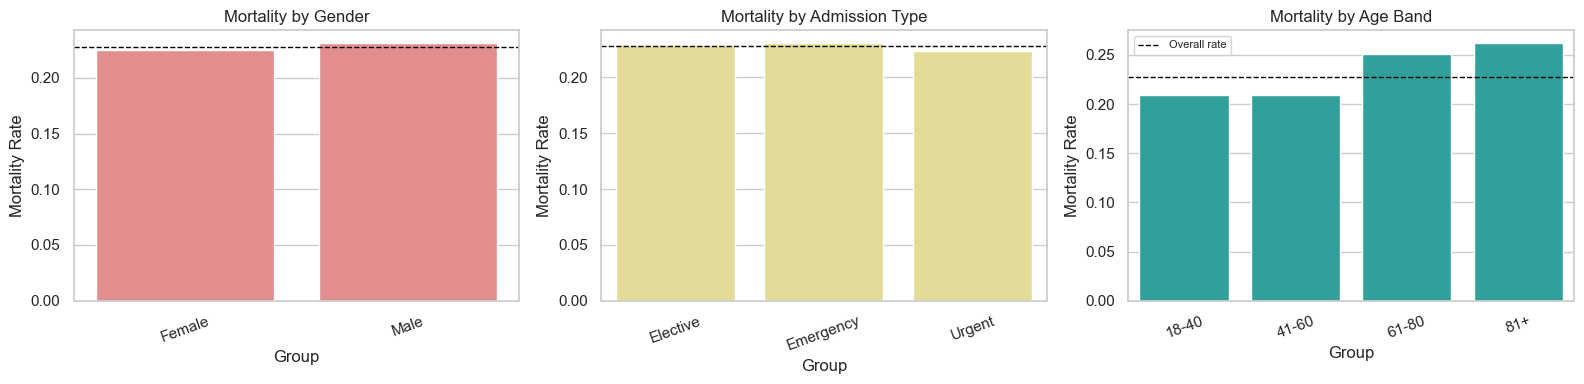

,group_type,group_value,sample_size,mortality_rate,population_share,rate_gap_vs_overall,relative_risk_vs_overall
0,gender,Female,7477,0.2247,0.4985,-0.0032,0.9861
1,gender,Male,7523,0.2310,0.5015,0.0032,1.0139
2,admission_type,Elective,5068,0.2289,0.3379,0.0010,1.0045
3,admission_type,Emergency,4965,0.2306,0.3310,0.0027,1.0121
4,admission_type,Urgent,4967,0.2241,0.3311,-0.0038,0.9834
5,age_band,18-40,4715,0.2091,0.3143,-0.0187,0.9177
6,age_band,41-60,4118,0.2091,0.2745,-0.0188,0.9176
7,age_band,61-80,4166,0.2513,0.2777,0.0235,1.1029
8,age_band,81+,2001,0.2619,0.1334,0.0340,1.1492


,group_type,group_value,sample_size,mortality_rate,rate_gap_vs_overall,relative_risk_vs_overall
0,age_band,81+,2001,0.2619,0.0340,1.1492
1,age_band,61-80,4166,0.2513,0.0235,1.1029
2,age_band,41-60,4118,0.2091,-0.0188,0.9176
3,age_band,18-40,4715,0.2091,-0.0187,0.9177
4,admission_type,Urgent,4967,0.2241,-0.0038,0.9834
5,gender,Female,7477,0.2247,-0.0032,0.9861
6,gender,Male,7523,0.2310,0.0032,1.0139
7,admission_type,Emergency,4965,0.2306,0.0027,1.0121


In [23]:
overall_rate = float(df['mortality_label'].mean())

frames = []
for col in ['gender', 'admission_type']:
    grp = (
        df.groupby(col)['mortality_label']
        .agg(sample_size='count', mortality_rate='mean')
        .reset_index()
        .rename(columns={col: 'group_value'})
    )
    grp.insert(0, 'group_type', col)
    frames.append(grp)

age_bins = [18, 40, 60, 80, 120]
age_labels = ['18-40', '41-60', '61-80', '81+']
df_age = df.assign(age_band=pd.cut(df['age'], bins=age_bins, labels=age_labels, include_lowest=True))
age_grp = (
    df_age.groupby('age_band', observed=False)['mortality_label']
    .agg(sample_size='count', mortality_rate='mean')
    .reset_index()
    .rename(columns={'age_band': 'group_value'})
)
age_grp.insert(0, 'group_type', 'age_band')
frames.append(age_grp)

fairness_summary = pd.concat(frames, ignore_index=True)
fairness_summary['population_share'] = fairness_summary['sample_size'] / len(df)
fairness_summary['rate_gap_vs_overall'] = fairness_summary['mortality_rate'] - overall_rate
fairness_summary['relative_risk_vs_overall'] = np.where(
    overall_rate > 0,
    fairness_summary['mortality_rate'] / overall_rate,
    np.nan
)
fairness_summary[['mortality_rate', 'population_share', 'rate_gap_vs_overall', 'relative_risk_vs_overall']] = fairness_summary[['mortality_rate', 'population_share', 'rate_gap_vs_overall', 'relative_risk_vs_overall']].round(4)
fairness_summary.to_csv(OUT_DIR / 'fairness_descriptive_summary.csv', index=False, encoding='utf-8-sig')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_specs = [
    ('gender', 'lightcoral', 'Mortality by Gender'),
    ('admission_type', 'khaki', 'Mortality by Admission Type'),
    ('age_band', 'lightseagreen', 'Mortality by Age Band')
]

for ax, (group_name, color, title) in zip(axes, plot_specs):
    data_plot = fairness_summary[fairness_summary['group_type'] == group_name]
    sns.barplot(x='group_value', y='mortality_rate', data=data_plot, ax=ax, color=color)
    ax.axhline(overall_rate, linestyle='--', color='black', linewidth=1, label='Overall rate')
    ax.set_title(title)
    ax.set_xlabel('Group')
    ax.set_ylabel('Mortality Rate')
    ax.tick_params(axis='x', rotation=20)

axes[-1].legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'du_step10_d7_fairness_descriptive.png', dpi=150, bbox_inches='tight')
plt.show()

fairness_priority = fairness_summary.sort_values('rate_gap_vs_overall', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
display(fairness_summary)
display(fairness_priority[['group_type', 'group_value', 'sample_size', 'mortality_rate', 'rate_gap_vs_overall', 'relative_risk_vs_overall']].head(8))

**Interpretasi:** D7 kini tidak hanya menampilkan 1 metrik, tetapi juga ukuran sampel, proporsi populasi, gap mortalitas terhadap overall, dan relative risk pada subgroup gender, admission type, dan age band. Ini membuat audit fairness deskriptif lebih informatif sebelum masuk tahap modeling.